# Solar Forecasting Prototype

This notebook develops a prototype Solar Forecasting System using the synthetic Omni-Grid dataset previously used for predictive maintenance and anomaly detection workflows.

The objective is to validate the forecasting pipeline, feature engineering process, baseline forecasting comparison, and XGBoost-based forecasting workflow within a controlled synthetic environment.

The prototype demonstrates:
- time-series preprocessing
- forecasting feature engineering
- persistence baseline modelling
- XGBoost forecasting
- evaluation and visualisation workflows

Results are prototype outputs based on synthetic data and are intended for architectural and workflow validation purposes only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("synthetic_predictive_maintenance_dataset.csv")

In [3]:
df.head()

,date,inverter_id,manufacturer,climate_zone,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,...,failed_today,is_censored,efficiency_7d_mean,efficiency_30d_mean,temperature_7d_mean,temperature_30d_mean,efficiency_decline_7d,temp_stress_index,restart_7d_sum,errors_7d_sum
0,2025-01-01,INV-0001,Fronius,Temperate,100,0.789,0.88,83.00,19.57,40.05,...,0,0,97.9300,97.9300,28.510000,28.510000,0.0000,0.0,0.0,0.0
1,2025-01-02,INV-0001,Fronius,Temperate,100,0.789,0.88,83.03,23.48,41.48,...,0,0,97.6950,97.6950,32.575000,32.575000,-0.2350,0.0,0.0,0.0
2,2025-01-03,INV-0001,Fronius,Temperate,100,0.789,0.88,83.07,21.69,45.80,...,0,0,97.8100,97.8100,32.456667,32.456667,0.2300,0.0,0.0,0.0
3,2025-01-04,INV-0001,Fronius,Temperate,100,0.789,0.88,83.10,21.43,22.49,...,0,0,97.7275,97.7275,33.117500,33.117500,-0.2475,0.0,0.0,0.0
4,2025-01-05,INV-0001,Fronius,Temperate,100,0.789,0.88,83.13,23.25,33.41,...,0,0,97.8680,97.8680,33.792000,33.792000,0.5620,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32627 entries, 0 to 32626
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              32627 non-null  object 
 1   inverter_id                       32627 non-null  object 
 2   manufacturer                      32627 non-null  object 
 3   climate_zone                      32627 non-null  object 
 4   rated_capacity_kw                 32627 non-null  int64  
 5   installation_quality_score        32627 non-null  float64
 6   maintenance_quality_score         32627 non-null  float64
 7   age_months                        32627 non-null  float64
 8   ambient_temperature_c             32627 non-null  float64
 9   humidity_pct                      32627 non-null  float64
 10  dust_soiling_index                32627 non-null  float64
 11  uv_exposure_index                 32627 non-null  float64
 12  cumu

In [5]:
df.columns

Index(['date', 'inverter_id', 'manufacturer', 'climate_zone',
       'rated_capacity_kw', 'installation_quality_score',
       'maintenance_quality_score', 'age_months', 'ambient_temperature_c',
       'humidity_pct', 'dust_soiling_index', 'uv_exposure_index',
       'cumulative_uv_exposure', 'operating_hours_today',
       'cumulative_operating_hours', 'cumulative_energy_throughput_mwh',
       'efficiency_pct', 'reactive_power_capability', 'internal_temperature_c',
       'voltage_ripple', 'current_harmonic_distortion_pct',
       'insulation_resistance_mohm', 'capacitor_degradation_indicator',
       'fan_speed_rpm', 'restart_count_today', 'error_code_count_today',
       'thermal_cycling_count_today', 'overload_events_today',
       'failure_within_7d', 'failure_within_30d', 'failure_within_90d',
       'rul_days', 'failed_today', 'is_censored', 'efficiency_7d_mean',
       'efficiency_30d_mean', 'temperature_7d_mean', 'temperature_30d_mean',
       'efficiency_decline_7d', 'temp_s

## Time-Series Preprocessing

This section prepares the dataset for forecasting by:
- converting the date column into datetime format
- sorting records chronologically
- selecting the forecasting target
- generating time-based features

In [6]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort chronologically
df = df.sort_values(by=['inverter_id', 'date'])

# Reset index
df = df.reset_index(drop=True)

# Forecast target
target = 'efficiency_pct'

# Display dataset info
print("Dataset Shape:", df.shape)
print("\nForecast Target:", target)

df[['date', 'inverter_id', target]].head()

Dataset Shape: (32627, 42)

Forecast Target: efficiency_pct


,date,inverter_id,efficiency_pct
0,2025-01-01,INV-0001,97.93
1,2025-01-02,INV-0001,97.46
2,2025-01-03,INV-0001,98.04
3,2025-01-04,INV-0001,97.48
4,2025-01-05,INV-0001,98.43


## Time-Based Feature Engineering

This section creates temporal features that help the forecasting model learn seasonal and cyclical patterns.

In [7]:
# Extract time-based features
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

# Cyclical encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)

df[['date', 'month', 'month_sin', 'month_cos']].head()

,date,month,month_sin,month_cos
0,2025-01-01,1,0.5,0.866025
1,2025-01-02,1,0.5,0.866025
2,2025-01-03,1,0.5,0.866025
3,2025-01-04,1,0.5,0.866025
4,2025-01-05,1,0.5,0.866025


## Lag Feature Engineering

Lag features allow the model to learn historical temporal dependencies by using previous observations of the target variable.

In [8]:
# Lag features
df['lag_1'] = df.groupby('inverter_id')[target].shift(1)
df['lag_3'] = df.groupby('inverter_id')[target].shift(3)
df['lag_7'] = df.groupby('inverter_id')[target].shift(7)

# Rolling statistics
df['rolling_mean_7'] = (
    df.groupby('inverter_id')[target]
    .transform(lambda x: x.rolling(window=7).mean())
)

df['rolling_std_7'] = (
    df.groupby('inverter_id')[target]
    .transform(lambda x: x.rolling(window=7).std())
)

df.head(10)

,date,inverter_id,manufacturer,climate_zone,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,...,day_of_week,month_sin,month_cos,day_sin,day_cos,lag_1,lag_3,lag_7,rolling_mean_7,rolling_std_7
0,2025-01-01,INV-0001,Fronius,Temperate,100,0.789,0.88,83.00,19.57,40.05,...,2,0.5,0.866025,0.201299,0.979530,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,INV-0001,Fronius,Temperate,100,0.789,0.88,83.03,23.48,41.48,...,3,0.5,0.866025,0.394356,0.918958,97.93,NaN,NaN,NaN,NaN
2,2025-01-03,INV-0001,Fronius,Temperate,100,0.789,0.88,83.07,21.69,45.80,...,4,0.5,0.866025,0.571268,0.820763,97.46,NaN,NaN,NaN,NaN
3,2025-01-04,INV-0001,Fronius,Temperate,100,0.789,0.88,83.10,21.43,22.49,...,5,0.5,0.866025,0.724793,0.688967,98.04,97.93,NaN,NaN,NaN
4,2025-01-05,INV-0001,Fronius,Temperate,100,0.789,0.88,83.13,23.25,33.41,...,6,0.5,0.866025,0.848644,0.528964,97.48,97.46,NaN,NaN,NaN
5,2025-01-06,INV-0001,Fronius,Temperate,100,0.789,0.88,83.17,22.86,40.87,...,0,0.5,0.866025,0.937752,0.347305,98.43,98.04,NaN,NaN,NaN
6,2025-01-07,INV-0001,Fronius,Temperate,100,0.789,0.88,83.20,20.69,43.24,...,1,0.5,0.866025,0.988468,0.151428,97.79,97.48,NaN,97.807143,0.357664
7,2025-01-08,INV-0001,Fronius,Temperate,100,0.789,0.88,83.23,24.84,53.73,...,2,0.5,0.866025,0.998717,-0.050649,97.52,98.43,97.93,97.847143,0.388060
8,2025-01-09,INV-0001,Fronius,Temperate,100,0.789,0.88,83.27,29.85,55.48,...,3,0.5,0.866025,0.968077,-0.250653,98.21,97.79,97.46,97.858571,0.375741
9,2025-01-10,INV-0001,Fronius,Temperate,100,0.789,0.88,83.30,29.51,51.80,...,4,0.5,0.866025,0.897805,-0.440394,97.54,97.52,98.04,97.878571,0.390445


In [21]:
# Additional lag features
df['lag_14'] = df.groupby('inverter_id')[target].shift(14)

# Rolling statistics
df['rolling_mean_14'] = (
    df.groupby('inverter_id')[target]
    .transform(lambda x: x.rolling(window=14).mean())
)

# Efficiency volatility
df['efficiency_volatility'] = (
    df['rolling_std_7'] / df['rolling_mean_7']
)

# Temperature interaction
df['temp_efficiency_interaction'] = (
    df['ambient_temperature_c'] * df['efficiency_7d_mean']
)

# UV and temperature interaction
df['uv_temp_interaction'] = (
    df['uv_exposure_index'] * df['ambient_temperature_c']
)

# Clean NaNs again
df = df.dropna()

print(df.shape)

(13939, 60)


In [9]:
# Drop rows with NaN values from lag features
df = df.dropna()

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (14961, 54)


## Persistence Baseline Forecast

A persistence model is used as a naive forecasting benchmark where the prediction is assumed to be equal to the previous observed value.

This establishes a minimum performance benchmark for evaluating the forecasting model.

In [10]:
# Persistence baseline prediction
df['baseline_prediction'] = df['lag_1']

# Actual values
y_true = df[target]

# Baseline predictions
y_baseline = df['baseline_prediction']

# Baseline metrics
baseline_mae = mean_absolute_error(y_true, y_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_true, y_baseline))
baseline_r2 = r2_score(y_true, y_baseline)

print("Persistence Baseline Performance")
print("--------------------------------")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Persistence Baseline Performance
--------------------------------
MAE  : 0.5801
RMSE : 0.7283
R²   : 0.9200


In [11]:
from xgboost import XGBRegressor

## XGBoost Forecasting Model

This section trains an XGBoost regression model using engineered temporal, environmental, and operational features to predict inverter efficiency as a proxy for solar generation performance.

In [22]:
# Feature selection
features = [
    'ambient_temperature_c',
    'humidity_pct',
    'dust_soiling_index',
    'uv_exposure_index',
    'thermal_cycling_count_today',
    'overload_events_today',
    'efficiency_7d_mean',
    'efficiency_30d_mean',
    'temperature_7d_mean',
    'temperature_30d_mean',
    'temp_stress_index',
    'restart_7d_sum',
    'errors_7d_sum',

    'lag_1',
    'lag_3',
    'lag_7',
    'lag_14',

    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_std_7',

    'efficiency_volatility',
    'temp_efficiency_interaction',
    'uv_temp_interaction',

    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos'
]

X = df[features]
y = df[target]

In [23]:
# Chronological split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (11151, 27)
Testing Shape : (2788, 27)


In [24]:
# XGBoost model
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [25]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Forecasting Performance")
print("--------------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

XGBoost Forecasting Performance
--------------------------------
MAE  : 0.3623
RMSE : 0.4557
R²   : 0.9699


In [26]:
print("Model Comparison")
print("----------------")
print(f"Baseline RMSE : {baseline_rmse:.4f}")
print(f"XGBoost RMSE  : {rmse:.4f}")

if rmse < baseline_rmse:
    print("\nXGBoost outperformed the persistence baseline.")
else:
    print("\nPersistence baseline performed better.")

Model Comparison
----------------
Baseline RMSE : 0.7283
XGBoost RMSE  : 0.4557

XGBoost outperformed the persistence baseline.


## Actual vs Predicted Forecast

This visual compares the actual inverter efficiency values against the XGBoost forecast predictions over the testing period.

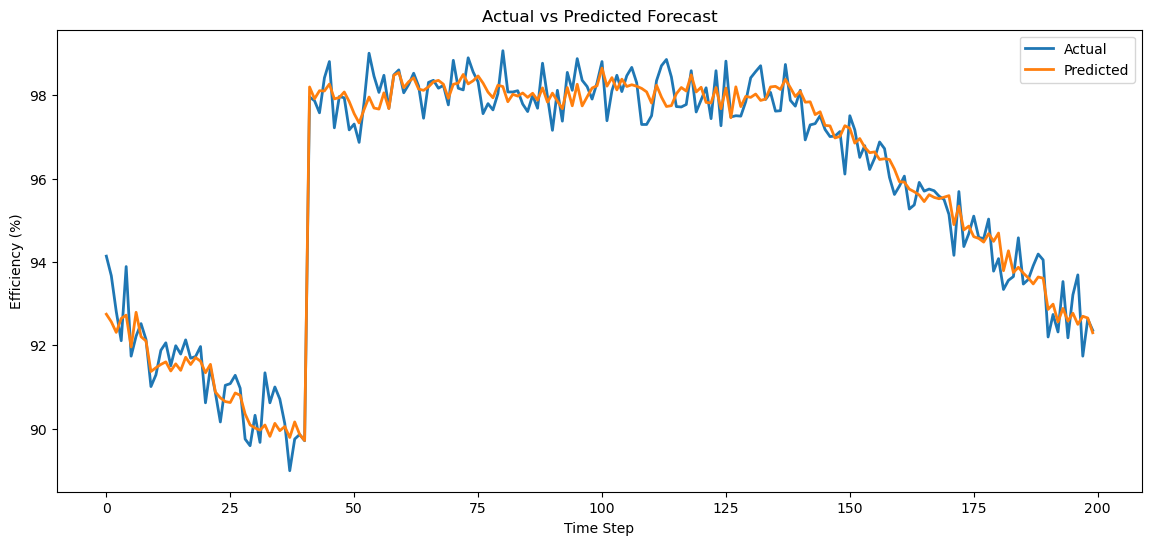

In [27]:
# Actual vs predicted plot
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:200],
    label='Actual',
    linewidth=2
)

plt.plot(
    y_pred[:200],
    label='Predicted',
    linewidth=2
)

plt.title('Actual vs Predicted Forecast')
plt.xlabel('Time Step')
plt.ylabel('Efficiency (%)')
plt.legend()

plt.show()

## Forecast Error Distribution

This plot visualises the distribution of forecasting residuals to assess prediction stability and bias.

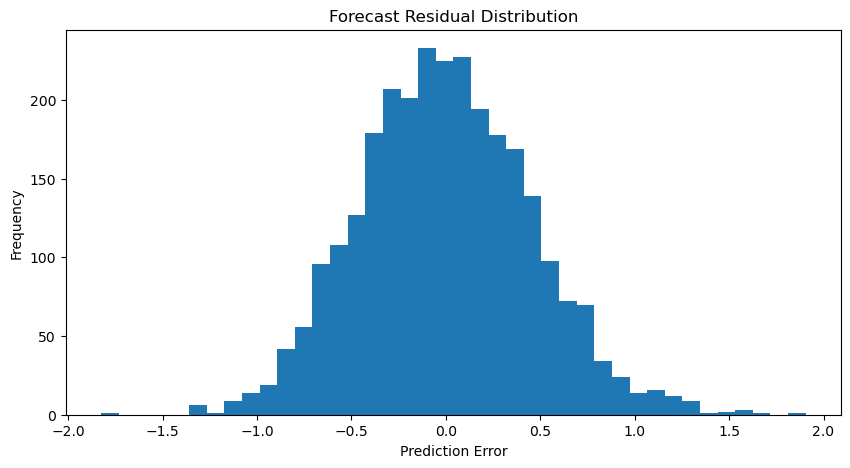

In [28]:
# Residuals
residuals = y_test.values - y_pred

# Residual distribution
plt.figure(figsize=(10,5))

plt.hist(residuals, bins=40)

plt.title('Forecast Residual Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')

plt.show()

## Baseline vs XGBoost Performance Comparison

This chart compares the forecasting error of the persistence baseline against the XGBoost forecasting model.

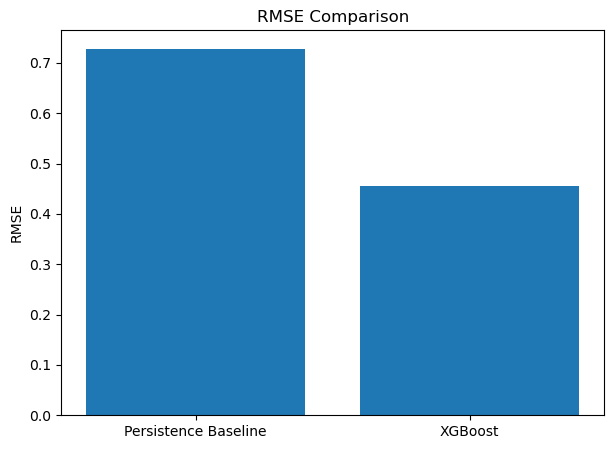

In [29]:
# Comparison chart
models = ['Persistence Baseline', 'XGBoost']
rmse_values = [baseline_rmse, rmse]

plt.figure(figsize=(7,5))

plt.bar(models, rmse_values)

plt.title('RMSE Comparison')
plt.ylabel('RMSE')

plt.show()

## Feature Importance Analysis

Feature importance analysis identifies which temporal, operational, and environmental variables contributed most strongly to forecasting performance.

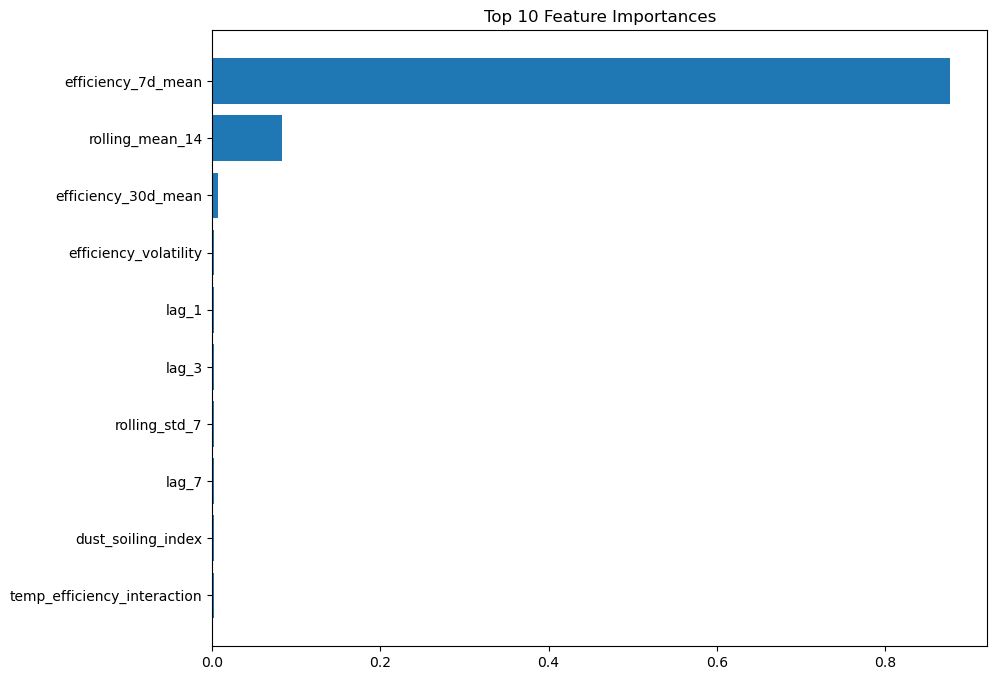

In [30]:
# Feature importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.gca().invert_yaxis()

plt.title('Top 10 Feature Importances')

plt.show()

In [31]:
import shap

## SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) is used to interpret the contribution of each feature toward forecasting predictions generated by the XGBoost model.

In [32]:
# SHAP explainer
explainer = shap.Explainer(model)

# SHAP values
shap_values = explainer(X_test)

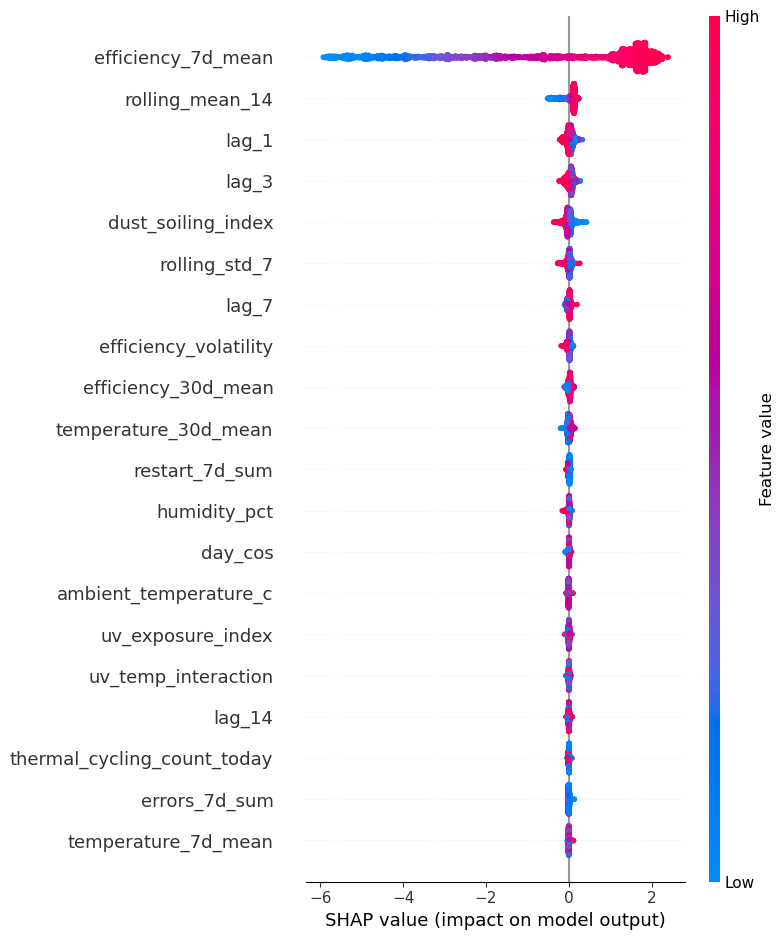

In [33]:
# SHAP summary plot
shap.summary_plot(shap_values, X_test)